In [1]:
import numpy as np
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path
from ms_pred import common
import csv
import re
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

/home/runzhong/mambaforge/envs/ms-gen-torch24/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-30 23:09:50,089	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-30 23:09:50,383	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
%cd ~/ms-pred

/mnt/home/runzhong/ms-pred


## Read MSn Lib

In [4]:
msn_specs = common.parse_spectra_mgf('data/spec_datasets/msnlib/all_specs.mgf')

366730it [00:19, 19010.60it/s]


In [5]:
ms2_specs = [_ for _ in msn_specs if _[0]['MS_LEVEL'] == '2']
ms2_ikeys = [common.inchikey_from_smiles(_[0]['SMILES']).split('-')[0] for _ in ms2_specs]

In [6]:
split_name = 'split_1'
nist_specs = pd.read_csv('data/spec_datasets/nist23/labels.tsv', sep='\t')
train_ind, val_ind, test_ind = common.get_splits(nist_specs['spec'].values, f'data/spec_datasets/nist20/splits/{split_name}.tsv')
nist_ikeys = [_.split('-')[0] for _ in nist_specs['inchikey']]

In [7]:
gnps_specs = pd.read_csv('data/spec_datasets/ALL_GNPS_cleaned.csv')
gnps_ikeys = [_.split('-')[0] for _ in gnps_specs['InChIKey_smiles'] if type(_) is str]

/tmp/ipykernel_228306/2470415587.py:1: DtypeWarning: Columns (4,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  gnps_specs = pd.read_csv('data/spec_datasets/ALL_GNPS_cleaned.csv')


In [8]:
# exclude every thing from GNPS and NIST'23
no_overlap_specs, no_overlap_ikeys = list(zip(*[(spec, ikey) for spec, ikey in zip(ms2_specs, ms2_ikeys) if not (ikey in nist_ikeys or ikey in gnps_ikeys)]))

In [9]:
f"num of specs w/o overlap with NIST'23 + GNPS: {len(no_overlap_specs)}, total specs: {len(ms2_ikeys)}, unique mols: {len(np.unique(no_overlap_ikeys))}"

"num of specs w/o overlap with NIST'23 + GNPS: 8834, total specs: 16476, unique mols: 8135"

In [10]:
new_mgf_list = []
feat_id_to_ikey = {}
feat_id = 0
for meta, spec in no_overlap_specs:
    new_meta = {k:v for k, v in meta.items() if not k in ['INCHI', 'SMILES', 'COMPOUND_NAME', 'ION_SOURCE']}
    if new_meta['ADDUCT'] not in common.ion2mass:
        continue
    new_meta['FEATURE_ID'] = feat_id
    feat_id_to_ikey[feat_id] = new_meta['INCHI_AUX'].split('-')[0]
    feat_id += 1
    new_mgf_list.append((new_meta, spec))
mgf_str = common.build_mgf_str(new_mgf_list)

In [13]:
dst_path = Path(f'results/sirius_eval/msnlib/all_specs.mgf')
dst_path.parent.mkdir(parents=True, exist_ok=True)
dst_path.write_text(mgf_str)

18770204

In [11]:
len(new_mgf_list)

8824

## Now, import all spectra to SIRIUS, and run the prediction, export output

In [11]:
sirius_pred = pd.read_csv(f'results/sirius_eval/msnlib/structure_identifications_all.tsv', sep='\t', quoting=csv.QUOTE_NONE)
sirius_pred

,structurePerIdRank,formulaRank,ConfidenceScoreExact,ConfidenceScoreApproximate,CSI:FingerIDScore,ZodiacScore,SiriusScore,molecularFormula,adduct,precursorFormula,...,pubchemids,links,dbflags,ionMass,retentionTimeInSeconds,retentionTimeInMinutes,formulaId,alignedFeatureId,mappingFeatureId,overallFeatureQuality
0,1,1,0.175,0.175,-335.127,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,74328572;9812479;102402201;162975498;162975499...,COCONUT:(CNP0247313);PUBCHEMANNOTATIONSAFETYAN...,70254610,635.333,NaN,NaN,764571276730634740,764570034717483899,0,NaN
1,2,1,0.175,0.175,-366.932,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,102402202;162857532;162857533,COCONUT:(CNP0120398);SUPERNATURAL:(SN0040902);...,3145730,635.333,NaN,NaN,764571276730634740,764570034717483899,0,NaN
2,3,1,0.175,0.175,-374.585,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,9812480;9986765;162816750;85044201;162993909;1...,COCONUT:(CNP0074230 CNP0267063);SUPERNATURAL:(...,3145814,635.333,NaN,NaN,764571276730634740,764570034717483899,0,NaN
3,4,1,0.175,0.175,-537.872,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,162849194;162849195,COCONUT:(CNP0111032);TeroMol:(TKC161874);SUPER...,279969794,635.333,NaN,NaN,764571276730634740,764570034717483899,0,NaN
4,5,1,0.175,0.175,-547.280,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,46906780,PUBCHEM:(46906780);PUBMED:(null),66,635.333,NaN,NaN,764571276730634740,764570034717483899,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19798034,156,1,0.085,0.085,-527.378,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,...,136482737,PUBCHEM:(136482737),2,457.106,NaN,NaN,764635248596559378,764570323906400042,8823,NaN
19798035,157,1,0.085,0.085,-545.633,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,...,164515289,PUBCHEM:(164515289),2,457.106,NaN,NaN,764635248596559378,764570323906400042,8823,NaN
19798036,158,1,0.085,0.085,-567.839,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,...,117972776,PUBCHEM:(117972776),2,457.106,NaN,NaN,764635248596559378,764570323906400042,8823,NaN
19798037,159,1,0.085,0.085,-593.565,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,...,129138832;129139154,PUBCHEM:(129138832 129139154),2,457.106,NaN,NaN,764635248596559378,764570323906400042,8823,NaN


In [12]:
sirius_summary = {}
wrong_form = set()
for idx, pred_entry in tqdm(sirius_pred.iterrows(), total=sirius_pred.shape[0]):
    feat_id = pred_entry['mappingFeatureId']
    true_ikey = feat_id_to_ikey[feat_id]
    pred_ikey = pred_entry['InChIkey2D']
    pred_score = pred_entry['CSI:FingerIDScore']

    gt_meta = new_mgf_list[feat_id][0]
    if len(common.formula_difference(gt_meta['FORMULA'], pred_entry['molecularFormula'])) > 0:
        wrong_form.add(feat_id)

    if feat_id not in sirius_summary:
        sirius_summary[feat_id] = {'adduct': pred_entry['adduct'], 'pred_matched': [], 'pred_scores': []}
    #if pred_ikey in cand_ikeys:
    sirius_summary[feat_id]['pred_matched'].append(pred_ikey == true_ikey)
    sirius_summary[feat_id]['pred_scores'].append(pred_score)
print(f'Wrong formula predictions: {len(wrong_form)}')

100%|██████████████████████████████████████████████████████████████████████████| 19798039/19798039 [20:08<00:00, 16383.43it/s]

Wrong formula predictions: 128


In [13]:
results = []
for feat_id, summary in sirius_summary.items():
    results.append(
        {
            'spec': feat_id,
            'adduct': summary['adduct'],
            'match_idx': summary['pred_matched'].index(True) + 1 if any(summary['pred_matched']) else 9999,
            'score': summary['pred_scores'][summary['pred_matched'].index(True)] if any(summary['pred_matched']) else -9999,
        }
    )
results = pd.DataFrame(results)
results

,spec,adduct,match_idx,score
0,0,[M - H2O + H]+,9999,-9999.000
1,1,[M + H]+,9999,-9999.000
2,2,[M + H3N + H]+,2,-79.882
3,3,[M + H]+,1,-133.241
4,4,[M - H4O2 + H]+,1,-71.446
...,...,...,...,...
8643,8819,[M + H]+,3,-204.646
8644,8820,[M + H]+,45,-247.771
8645,8821,[M + H]+,1,-138.135
8646,8822,[M + H]+,4,-176.840


In [14]:
results[results['match_idx'] == 9999].shape

(42, 4)

In [15]:
# top-k accuracy
for k in range(1, 11):
    print(f'top-{k} acc', results[results['match_idx'] <= k].shape[0] / results.shape[0])

top-1 acc 0.15830249768732654
top-2 acc 0.2330018501387604
top-3 acc 0.28295559666975023
top-4 acc 0.3177613320999075
top-5 acc 0.343432007400555
top-6 acc 0.36262719703977797
top-7 acc 0.3861008325624422
top-8 acc 0.40020814061054577
top-9 acc 0.41304347826086957
top-10 acc 0.42564754856614245


# Import SIRIUS prediction with bio-only candidates (SIRIUS 6.0.6 default)

In [18]:
sirius_pred_bioonly = pd.read_csv(f'results/sirius_eval/msnlib/bio_only_structure_identifications_top-10.tsv', sep='\t', quoting=csv.QUOTE_NONE)
sirius_pred_bioonly

,structurePerIdRank,formulaRank,ConfidenceScoreExact,ConfidenceScoreApproximate,CSI:FingerIDScore,ZodiacScore,SiriusScore,molecularFormula,adduct,precursorFormula,...,pubchemids,links,dbflags,ionMass,retentionTimeInSeconds,retentionTimeInMinutes,formulaId,alignedFeatureId,mappingFeatureId,overallFeatureQuality
0,1,1,0.254,0.254,-335.127,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,74328572;9812479;102402201;162975498;162975499...,COCONUT:(CNP0247313);PUBCHEMANNOTATIONSAFETYAN...,70254610,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
1,2,1,0.254,0.254,-366.932,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,102402202;162857532;162857533,COCONUT:(CNP0120398);SUPERNATURAL:(SN0040902);...,3145730,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
2,3,1,0.254,0.254,-374.585,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,9812480;9986765;162816750;85044201;162993909;1...,COCONUT:(CNP0074230 CNP0267063);SUPERNATURAL:(...,3145814,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
3,4,1,0.254,0.254,-537.872,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,...,162849194;162849195,COCONUT:(CNP0111032);TeroMol:(TKC161874);SUPER...,279969794,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
4,1,1,0.240,0.260,-342.240,NaN,165.341,C36H48N2O9,[M + H]+,C36H49N2O9+,...,74328572;9812479;102402201;162975498;162975499...,COCONUT:(CNP0247313);PUBCHEMANNOTATIONSAFETYAN...,70254610,653.343,NaN,NaN,767052424919810968,767051922433758331,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66491,6,1,0.092,0.092,-233.254,NaN,22.110,C24H20ClN3OS3,[M + H]+,C24H21ClN3OS3+,...,139219784,PUBCHEM:(139219784),2,498.053,NaN,NaN,767085728860650772,767052094970691616,8822,NaN
66492,7,1,0.092,0.092,-248.199,NaN,22.110,C24H20ClN3OS3,[M + H]+,C24H21ClN3OS3+,...,3197513,PUBCHEM:(3197513),2,498.053,NaN,NaN,767085728860650772,767052094970691616,8822,NaN
66493,8,1,0.092,0.092,-255.522,NaN,22.110,C24H20ClN3OS3,[M + H]+,C24H21ClN3OS3+,...,2119569,PUBCHEM:(2119569),2,498.053,NaN,NaN,767085728860650772,767052094970691616,8822,NaN
66494,1,1,0.263,0.263,-219.983,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,...,2257249,CHEBI:(132811);MESH:(2257249);PUBCHEM:(2257249...,102,457.106,NaN,NaN,767085739908448034,767052094970691621,8823,NaN


In [19]:
sirius_summary_bioonly = {}
wrong_form_bioonly = set()
for idx, pred_entry in tqdm(sirius_pred_bioonly.iterrows(), total=sirius_pred_bioonly.shape[0]):
    feat_id = pred_entry['mappingFeatureId']
    true_ikey = feat_id_to_ikey[feat_id]
    pred_ikey = pred_entry['InChIkey2D']
    pred_score = pred_entry['CSI:FingerIDScore']

    gt_meta = new_mgf_list[feat_id][0]
    if len(common.formula_difference(gt_meta['FORMULA'], pred_entry['molecularFormula'])) > 0:
        wrong_form_bioonly.add(feat_id)

    if feat_id not in sirius_summary_bioonly:
        sirius_summary_bioonly[feat_id] = {'adduct': pred_entry['adduct'], 'pred_matched': [], 'pred_scores': []}
    #if pred_ikey in cand_ikeys:
    sirius_summary_bioonly[feat_id]['pred_matched'].append(pred_ikey == true_ikey)
    sirius_summary_bioonly[feat_id]['pred_scores'].append(pred_score)
print(f'Wrong formula predictions: {len(wrong_form_bioonly)}')

100%|█████████████████████████████████████████████████████████████████████████████████| 66496/66496 [00:07<00:00, 8612.07it/s]

Wrong formula predictions: 128


In [20]:
results_bioonly = []
for feat_id, summary in sirius_summary_bioonly.items():
    results_bioonly.append(
        {
            'spec': feat_id,
            'adduct': summary['adduct'],
            'match_idx': summary['pred_matched'].index(True) + 1 if any(summary['pred_matched']) else 9999,
            'score': summary['pred_scores'][summary['pred_matched'].index(True)] if any(summary['pred_matched']) else -9999,
        }
    )
results_bioonly = pd.DataFrame(results_bioonly)
results_bioonly

,spec,adduct,match_idx,score
0,0,[M - H2O + H]+,9999,-9999.000
1,1,[M + H]+,9999,-9999.000
2,2,[M + H3N + H]+,2,-79.882
3,3,[M + H]+,1,-133.241
4,4,[M - H4O2 + H]+,1,-71.446
...,...,...,...,...
8643,8819,[M + H]+,1,-204.646
8644,8820,[M + H]+,1,-247.771
8645,8821,[M + H]+,1,-138.135
8646,8822,[M + H]+,4,-176.840


In [21]:
# top-k accuracy
for k in range(1, 11):
    print(f'top-{k} acc', results_bioonly[results_bioonly['match_idx'] <= k].shape[0] / results_bioonly.shape[0])

top-1 acc 0.3145235892691952
top-2 acc 0.377890841813136
top-3 acc 0.4118871415356152
top-4 acc 0.43362627197039777
top-5 acc 0.4478492136910268
top-6 acc 0.4598751156336725
top-7 acc 0.469472710453284
top-8 acc 0.4769888991674376
top-9 acc 0.4838112858464385
top-10 acc 0.4914431082331175


# Import SIRIUS/MSNovelist de novo results

In [219]:
sirius_pred_denovo = pd.read_csv(f'results/sirius_eval/msnlib/denovo_structure_identifications_top-10.tsv', sep='\t', quoting=csv.QUOTE_NONE)
sirius_pred_denovo

,structurePerIdRank,formulaRank,CSI:FingerIDScore,ModelScore,ZodiacScore,SiriusScore,molecularFormula,adduct,precursorFormula,InChIkey2D,InChI,name,smiles,ionMass,retentionTimeInSeconds,retentionTimeInMinutes,formulaId,alignedFeatureId,mappingFeatureId,overallFeatureQuality
0,1,1,-366.850,-12.120,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,BIJPGFQATZUNGC,InChI=1S/C36H48N2O9/c1-19-15-26-31(37-24(6)34(...,NaN,COC1CC(C)CC2=C(NC(C)C(OC(C)=O)C(C)=CC(C)C1O)C(...,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
1,2,1,-398.894,-12.667,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,JGBVFHLUIPCBRV,InChI=1S/C36H48N2O9/c1-11-21(4)35(42)38-31-25-...,NaN,C=CC(=O)OC1C(C)=CC(C)C(OC)C(OC)CC(C)CC2=C(NC(=...,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
2,3,1,-406.017,-12.732,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,GXQQWKUASVYXKE,InChI=1S/C36H48N2O9/c1-20-16-25-31(37-24-13-14...,NaN,COC1C=CC=C(C)C(=O)NC2=CC(=O)C(NC3CC3)=C(CC(C)C...,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
3,4,1,-406.504,-13.191,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,HUVSVTKNUUZDLD,InChI=1S/C36H48N2O9/c1-20-15-26-31(37-6)28(39)...,NaN,CNC1=C2CC(C)CC(OC)C(O)C(C)C=C(C)C(OC(=O)C(C)=C...,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
4,5,1,-408.818,-13.051,NaN,127.306,C36H48N2O9,[M - H2O + H]+,C36H47N2O8+,CYPDHTJMNKZXAF,InChI=1S/C36H48N2O9/c1-19-15-25-32(37-24-11-12...,NaN,COC1C=CC=C(C)C(=O)NC2=CC(=O)C(NC3CC3)=C(CC(C)C...,635.333,NaN,NaN,767052424261305030,767051922370843766,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85590,6,1,-222.696,-7.203,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,YZSATQSVZJLALO,InChI=1S/C25H17ClN4O3/c26-19-8-12-20(13-9-19)2...,NaN,O=c1c2c(-c3ccc([N+](=O)[O-])cc3)n(-c3ccc(Cl)cc...,457.106,NaN,NaN,767085739908448034,767052094970691621,8823,NaN
85591,7,1,-239.599,-7.986,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,WKWXUJGZJCEZNU,InChI=1S/C25H17ClN4O3/c1-15-18(8-9-22(26)21(15...,NaN,Cc1c(-c2cc(C(=O)NCc3ccccc3)c3cc([N+](=O)[O-])c...,457.106,NaN,NaN,767085739908448034,767052094970691621,8823,NaN
85592,8,1,-241.715,-7.327,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,VJNIIMLXOPKNPA,InChI=1S/C25H17ClN4O3/c26-20-8-12-21(13-9-20)2...,NaN,O=c1c2c(-c3ccc([N+](=O)[O-])cc3)n(Cc3ccccc3)cc...,457.106,NaN,NaN,767085739908448034,767052094970691621,8823,NaN
85593,9,1,-243.462,-7.039,NaN,6.709,C25H17ClN4O3,[M + H]+,C25H18ClN4O3+,AACIIVQODIJEAL,InChI=1S/C25H17ClN4O3/c26-19-11-13-20(14-12-19...,NaN,O=c1c2c(-c3ccccc3)n(Cc3ccccc3)c([N+](=O)[O-])c...,457.106,NaN,NaN,767085739908448034,767052094970691621,8823,NaN


In [220]:
sirius_summary_denovo = {}
wrong_form_denovo = set()
for idx, pred_entry in tqdm(sirius_pred_denovo.iterrows(), total=sirius_pred_denovo.shape[0]):
    feat_id = pred_entry['mappingFeatureId']
    true_ikey = feat_id_to_ikey[feat_id]
    pred_ikey = pred_entry['InChIkey2D']

    gt_meta = new_mgf_list[feat_id][0]
    if len(common.formula_difference(gt_meta['FORMULA'], pred_entry['molecularFormula'])) > 0:
        wrong_form_denovo.add(feat_id)

    if feat_id not in sirius_summary_denovo:
        sirius_summary_denovo[feat_id] = {'adduct': pred_entry['adduct'], 'pred_matched': []}
    #if pred_ikey in cand_ikeys:
    sirius_summary_denovo[feat_id]['pred_matched'].append(pred_ikey == true_ikey)
print(f'Wrong formula predictions: {len(wrong_form_denovo)}')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 85595/85595 [00:04<00:00, 21292.93it/s]

Wrong formula predictions: 106


In [221]:
results_denovo = []
for feat_id, summary in sirius_summary_denovo.items():
    results_denovo.append(
        {
            'spec': feat_id,
            'adduct': summary['adduct'],
            'match_idx': summary['pred_matched'].index(True) + 1 if any(summary['pred_matched']) else 9999,
        }
    )
results_denovo = pd.DataFrame(results_denovo)
results_denovo

,spec,adduct,match_idx
0,0,[M - H2O + H]+,9999
1,1,[M + H]+,9999
2,2,[M + H3N + H]+,9999
3,3,[M + H]+,1
4,4,[M - H4O2 + H]+,9999
...,...,...,...
8563,8819,[M + H]+,9999
8564,8820,[M + H]+,9999
8565,8821,[M + H]+,9999
8566,8822,[M + H]+,9999


In [222]:
# top-k accuracy
for k in range(1, 11):
    print(f'top-{k} acc', results_denovo[results_denovo['match_idx'] <= k].shape[0] / results_denovo.shape[0])

top-1 acc 0.028478057889822595
top-2 acc 0.04084967320261438
top-3 acc 0.04738562091503268
top-4 acc 0.051470588235294115
top-5 acc 0.05590569561157797
top-6 acc 0.05859010270774977
top-7 acc 0.061391223155929035
top-8 acc 0.06372549019607843
top-9 acc 0.06664332399626517
top-10 acc 0.06816059757236227


# ICEBERG prediction on MSnLib

In [23]:
import copy
from ms_pred.iceberg.iceberg_elucidation import candidates_from_pubchem, iceberg_prediction, load_real_spec, load_pred_spec, elucidation_over_candidates, plot_top_mols, explain_peaks, modi_finder, load_global_config, sanitize_smiles
config = load_global_config()
local_config = copy.deepcopy(config)
local_config['nce'] = True  # nce is used instead of eV values in the MS/MS file for collision energy

In [24]:
import pickle
form_to_smi_mapping = pickle.load(open('data/retrieval/pubchem/pubchem_formula_map.p', 'rb'))

In [18]:
all_smiles_and_forms = []
for feat_id, (meta, spec) in tqdm(enumerate(new_mgf_list)):
    if meta['FORMULA'] in form_to_smi_mapping and common.has_valid_els(meta['FORMULA']) and feat_id not in wrong_form:
        smile_ikeys = form_to_smi_mapping[meta['FORMULA']]
        all_smiles_and_forms.append(([smi for smi, ikey in smile_ikeys], meta['FORMULA']))
    else:
        all_smiles_and_forms.append(([], ''))

8824it [00:03, 2233.95it/s]


In [20]:
# all_smiles = []
# for smi, form in tqdm(all_smiles_and_forms):
#     all_smiles.append(sanitize_smiles(smi, form))
all_smiles = common.chunked_parallel(all_smiles_and_forms, sanitize_smiles, chunks=8000, max_cpu=96)

100%|███████████████████████████████████████████████████████████████████████████████| 8824/8824 [31:46<00:00,  4.63it/s]


In [27]:
entries = []
for feat_id, (smiles, (meta, spec)) in tqdm(enumerate(zip(all_smiles, new_mgf_list))):
    if feat_id in wrong_form:  # SIRIUS has wrong formula prediction
        continue
    if len(smiles) == 0:
        continue
    adduct = meta['ADDUCT']
    pmz = f"{common.formula_mass(meta['FORMULA']) + common.ion2mass[adduct]:.4f}"
    ce = [common.nce_to_ev(int(float(meta['COLLISION_ENERGY'])), float(pmz))]
    for smi in smiles:
        entries.append({
            'spec': f'{feat_id}', 'smiles': smi, 'ionization': adduct, 'inchikey': common.inchikey_from_smiles(smi),
            'precursor': pmz, 'collision_energies': ce,
        })
df = pd.DataFrame.from_dict(entries)
df.to_csv('results/sirius_eval/msnlib/cands_df_pubchem_all.tsv', sep='\t', index=False)

8824it [2:14:08,  1.10it/s]


OSError: Cannot save file into a non-existent directory: 'data/sirius_eval/msnlib'

## Run ICEBERG prediction on this tsv, the following are post processing

In [24]:
preds = common.HDF5Dataset('results/sirius_eval/msnlib/retrieval_pubchem_all/binned_preds.hdf5')

In [25]:
# confidence model
import joblib

MODEL_DIR = Path('results/dag_inten_nist20/split_1_rnd1/retrieval_confidence')
KS = [1, 3, 5, 10]
# confidence models
loaded = {}
topk_features_expected = None

for k in KS:
    payload = joblib.load(MODEL_DIR / f"lr_conf_k{k}.joblib")
    loaded[k] = payload["pipeline"]
    if topk_features_expected is None:
        topk_features_expected = int(payload["topk_features"])
    else:
        assert topk_features_expected == int(payload["topk_features"]), "topk_features mismatch across models"

TOPK_FEATURES = topk_features_expected  # e.g., 15
print("Loaded k models:", list(loaded.keys()), "TOPK_FEATURES=", TOPK_FEATURES)

Loaded k models: [1, 3, 5, 10] TOPK_FEATURES= 15


In [26]:
# ----------------------------
# Feature engineering (must match training)
# ----------------------------
def ion_onehot(ion: str) -> np.ndarray:
    n_ions = max(common.ion2onehot_pos.values()) + 1
    vec = np.zeros(n_ions, dtype=np.float32)
    if ion is None:
        return vec
    idx = common.ion2onehot_pos.get(ion)
    if idx is None:
        return vec
    vec[idx] = 1.0
    return vec

def build_feature_matrix_from_row(row: dict, topk_features: int) -> np.ndarray:
    # numeric: top_i_dist + mass + num_peaks_avg
    x_num = np.array(
        [row.get(f"top_{i}_dist", np.nan) for i in range(1, topk_features + 1)]
        + [row.get("mass", np.nan), row.get("num_peaks_avg", np.nan)],
        dtype=np.float32,
    )
    x_ion = ion_onehot(row.get("ion", None)).astype(np.float32)
    return np.concatenate([x_num, x_ion], axis=0)


In [34]:
from ms_pred.retrieval.retrieval_benchmark import dist_bin

num_bins = 15000
ignore_precursor = True
dist_func = "entropy"

iceberg_results = []
no_pubchem = set()

for pred_id, pred_spec_obj in tqdm(preds.h5_obj.items()):
    feat_id = int(pred_id.replace("pred_", ""))

    # load preds from hdf5
    pred_spec_ars = []
    pred_ikeys = []
    for ikey, smiles_obj in pred_spec_obj.items():
        spec_dict = {}
        for collision_eng_key, collision_eng_obj in smiles_obj.items():
            collision_eng_key = common.get_collision_energy(collision_eng_key)
            spec_dict[collision_eng_key] = collision_eng_obj["spec"][:]
        pred_spec_ars.append(spec_dict)
        pred_ikeys.append(ikey.replace("ikey ", "").split("-")[0])
    pred_ikeys = np.array(pred_ikeys)

    # load real
    real_meta, real_spec = new_mgf_list[feat_id]
    precursor_mz = float(real_meta["PRECURSOR_MZ"])
    adduct = real_meta.get("ADDUCT", None)

    real_spectrum = load_real_spec(
        {"collision " + real_meta["COLLISION_ENERGY"]: real_spec},
        "raw",
        precursor_mz,
        nce=True,
    )
    real_binned = {k: common.bin_spectra([v], num_bins)[0] for k, v in real_spectrum.items()}

    dist = dist_bin(
        pred_spec_ars,
        real_binned,
        ignore_peak=(precursor_mz - 1) * 10 if ignore_precursor else None,
        sparse=True,
        func=dist_func,
    )

    sorted_indices = np.argsort(dist)
    ranked_ikeys = pred_ikeys[sorted_indices]

    # rank of correct ikey (if present)
    rank_idx = np.where(np.array(ranked_ikeys) == feat_id_to_ikey[feat_id])[0]
    match_idx = rank_idx[0] + 1 if len(rank_idx) > 0 else 9999
    if len(rank_idx) == 0:
        no_pubchem.add(feat_id)

    # build top-k distance features from sorted distances
    sorted_dist = dist[sorted_indices]
    row = {
        "spec": feat_id,
        "adduct": adduct,
        "ion": adduct,               # IMPORTANT: model expects 'ion' like '[M+H]+' / '[M-H]-'
        "mass": precursor_mz,
        "num_peaks_avg": float(np.mean([np.sum(sp.intens > 0) for sp in real_spectrum.values()])),
        "num_collision_engs": len(real_spectrum.values()),
        "match_idx": int(match_idx),
    }
    for i in range(1, TOPK_FEATURES + 1):
        row[f"top_{i}_dist"] = float(sorted_dist[i - 1]) if len(sorted_dist) >= i else np.nan

    # compute confidence scores for k=1/3/5/10
    x = build_feature_matrix_from_row(row, topk_features=TOPK_FEATURES).reshape(1, -1)
    for k in KS:
        row[f"score_k{k}"] = float(loaded[k].predict_proba(x)[:, 1][0])

    iceberg_results.append(row)

iceberg_results = pd.DataFrame(iceberg_results)
iceberg_results

 40%|████████████████████████████████▎                                                | 3463/8693 [4:13:13<2:57:54,  2.04s/it]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [35]:
iceberg_results

,spec,adduct,ion,mass,num_peaks_avg,num_collision_engs,match_idx,top_1_dist,top_2_dist,top_3_dist,...,top_10_dist,top_11_dist,top_12_dist,top_13_dist,top_14_dist,top_15_dist,score_k1,score_k3,score_k5,score_k10
0,0,[M+H-H2O]+,[M+H-H2O]+,635.33270,61.0,1,9999,0.638335,0.651610,0.671406,...,0.761788,0.765065,0.775245,0.776962,0.811158,0.815841,0.351933,0.505274,0.595015,0.756652
1,1,[M+H]+,[M+H]+,653.34326,86.0,1,9999,0.661019,0.669384,0.672126,...,0.742870,0.762853,0.764007,0.766733,0.770788,0.776907,0.346481,0.578351,0.700472,0.781402
2,10,[M+H]+,[M+H]+,859.45466,43.0,1,2,0.555458,0.571807,0.572884,...,NaN,NaN,NaN,NaN,NaN,NaN,0.175134,0.033117,0.075359,0.279141
3,100,[M+Na]+,[M+Na]+,421.17339,11.0,1,5685,0.624152,0.640999,0.653331,...,0.675117,0.677883,0.679133,0.679880,0.680634,0.682913,0.296363,0.209817,0.227689,0.182900
4,1000,[M+H]+,[M+H]+,437.17950,37.0,1,1,0.239099,0.403280,0.451082,...,0.591116,0.594182,0.602336,0.603695,0.606977,0.608141,0.877948,0.904494,0.920645,0.933639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,995,[M+H]+,[M+H]+,336.11651,49.0,1,1,0.368596,0.380607,0.397388,...,0.549302,0.559958,0.560059,0.562326,0.570674,0.574321,0.474934,0.750407,0.770448,0.762977
8689,996,[M+H]+,[M+H]+,354.18524,63.0,1,2,0.461686,0.497849,0.523949,...,0.618136,0.620114,0.628654,0.633723,0.641662,0.642637,0.527062,0.741953,0.768368,0.719617
8690,997,[M+H]+,[M+H]+,370.21252,123.0,1,64,0.533122,0.534542,0.544015,...,0.568561,0.569429,0.572409,0.574324,0.575806,0.576076,0.371790,0.671372,0.711648,0.705787
8691,998,[M+H]+,[M+H]+,375.19145,16.0,1,12,0.469177,0.583111,0.587256,...,0.636758,0.641406,0.652948,0.656910,0.665347,0.667297,0.646502,0.483296,0.481652,0.521616


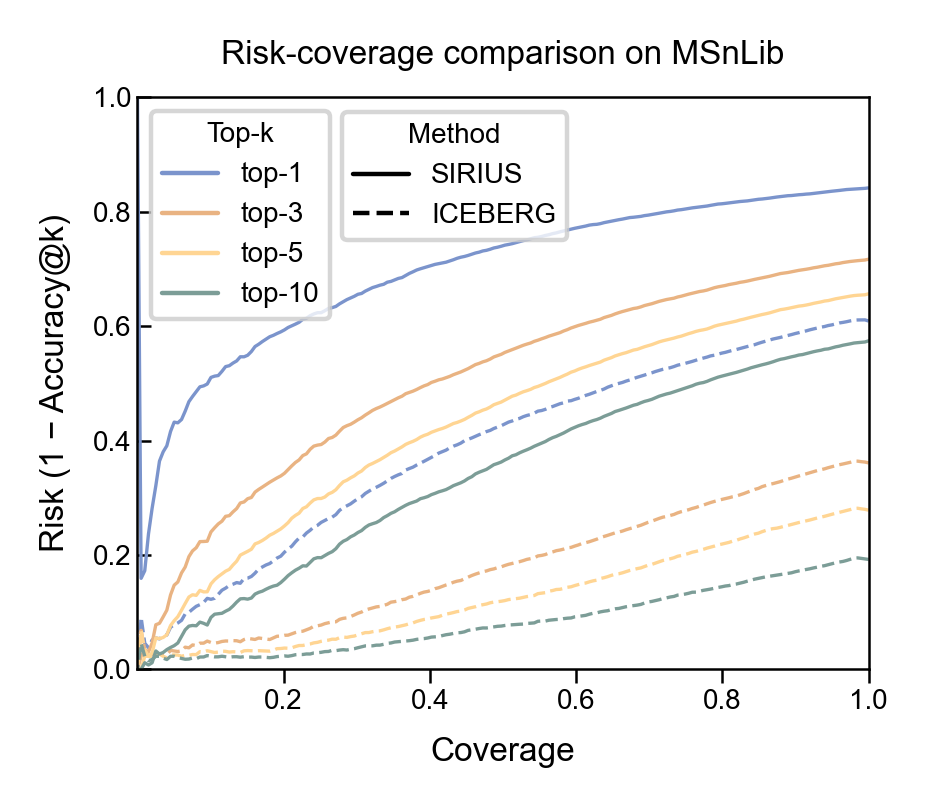

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from ms_pred.common.plot_utils import set_style

set_style()


def risk_coverage_curve_one_k(
    df: pd.DataFrame,
    rank_col: str,
    score_col: str,
    k: int,
    n_thresholds: int = 200,
):
    """
    Compute a single Risk–Coverage curve for top-k success using df[rank_col] and df[score_col].
    Returns: (coverage_array, risk_array)
    """
    data = df[[rank_col, score_col]].dropna().copy()
    ranks = data[rank_col].astype(int).to_numpy()
    scores = data[score_col].astype(float).to_numpy()

    N = len(scores)
    if N == 0:
        raise ValueError(f"No valid rows after filtering for score_col={score_col!r}.")

    # thresholds over confidence score (higher = better)
    thresholds = np.quantile(scores, np.linspace(0, 1, n_thresholds))

    coverages = []
    risks = []

    for t in thresholds:
        mask = scores >= t
        n_accept = int(mask.sum())
        if n_accept == 0:
            continue

        acc_k = np.mean(ranks[mask] <= k)
        coverages.append(n_accept / N)
        risks.append(1.0 - acc_k)

    return np.asarray(coverages), np.asarray(risks)


def risk_coverage_curves_mixed_scores(
    df: pd.DataFrame,
    rank_col: str,
    ks=(1, 3, 5, 10),
    score_col_by_k=None,
    n_thresholds: int = 200,
):
    """
    Compute dict[k] = (coverage, risk) where score column can differ by k.
    """
    if score_col_by_k is None:
        raise ValueError("Provide score_col_by_k, e.g. {1:'score', 3:'score', ...}")

    curves = {}
    for k in ks:
        score_col = score_col_by_k[k]
        curves[k] = risk_coverage_curve_one_k(
            df=df,
            rank_col=rank_col,
            score_col=score_col,
            k=k,
            n_thresholds=n_thresholds,
        )
    return curves

COLORS = {
    1: '#7B94CC',
    3: '#E9B382',
    5: '#FFD593',
    10: '#7C9D97',
}


def plot_risk_coverage_compare(
    curves_a,
    curves_b,
    label_a="SIRIUS",
    label_b="ICEBERG",
    title="Risk–Coverage Comparison",
):
    plt.figure(figsize=(2.3, 2), dpi=400)

    ks = sorted(set(curves_a.keys()) | set(curves_b.keys()))
    linestyles = {label_a: "-", label_b: "--"}

    # --- plot curves ---
    for k in ks:
        color = COLORS[k]

        if k in curves_a:
            cov, risk = curves_a[k]
            plt.plot(cov, risk, color=color, linestyle="-", linewidth=0.6)

        if k in curves_b:
            cov, risk = curves_b[k]
            plt.plot(cov, risk, color=color, linestyle="--", linewidth=0.6)

    plt.xlabel("Coverage")
    plt.ylabel("Risk (1 − Accuracy@k)")
    plt.title(title)

    # -------------------------
    # Custom merged legend
    # -------------------------

    # Color handles (top-k)
    color_handles = [
        Line2D([0], [0], color=COLORS[k], lw=0.8, label=f"top-{k}")
        for k in ks
    ]

    # Line style handles (methods)
    style_handles = [
        Line2D([0], [0], color="black", lw=0.8, linestyle="-", label=label_a),
        Line2D([0], [0], color="black", lw=0.8, linestyle="--", label=label_b),
    ]

    # First legend: colors
    legend1 = plt.legend(
        handles=color_handles,
        title="Top-k",
        loc="upper left",
        frameon=True,
        title_fontsize=5,
    )

    # Second legend: line styles
    legend2 = plt.legend(
        handles=style_handles,
        title="Method",
        loc=(0.28, 0.75),
        frameon=True,
        title_fontsize=5,
    )

    plt.gca().add_artist(legend1)
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.gca().set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
#     plt.gca().set_xticklabels(["", "0.2", "0.4", "0.6", "0.8", "1.0"])

    plt.tight_layout()

# ----------------------------
# Usage
# ----------------------------
KS = [1, 3, 5, 10]

# results_sirius: DataFrame with columns ["match_idx", "score", ...]
# results_iceberg: DataFrame with columns ["match_idx", "score_k1", "score_k3", "score_k5", "score_k10", ...]

sirius_score_map = {k: "score" for k in KS}
iceberg_score_map = {1: "score_k1", 3: "score_k1", 5: "score_k1", 10: "score_k1"}

curves_sirius = risk_coverage_curves_mixed_scores(
    results,
    rank_col="match_idx",
    ks=KS,
    score_col_by_k=sirius_score_map,
    n_thresholds=200,
)

curves_iceberg = risk_coverage_curves_mixed_scores(
    iceberg_results,
    rank_col="match_idx",
    ks=KS,
    score_col_by_k=iceberg_score_map,
    n_thresholds=200,
)

plot_risk_coverage_compare(
    curves_sirius,
    curves_iceberg,
    label_a="SIRIUS",
    label_b="ICEBERG",
    title="Risk-coverage comparison on MSnLib",
)
plt.savefig("results/figs_iceberg/weave_acc/iceberg_sirius_risk_coverage.pdf", bbox_inches="tight", transparent=True)

# ICEBERG using COCONUT as candidate

In [224]:
coconut_df = pd.read_csv('data/coconut_csv_lite-10-2025.csv')
coconut_df

,id,identifier,canonical_smiles,standard_inchi,standard_inchi_key,name,iupac_name,annotation_level,total_atom_count,heavy_atom_count,...,murcko_framework,np_likeness,chemical_class,chemical_sub_class,chemical_super_class,direct_parent_classification,np_classifier_pathway,np_classifier_superclass,np_classifier_class,np_classifier_is_glycoside
0,192952,CNP0413529.0,COC(=O)CC(C1=CC2=CC=C(OC)C=C2NC1=O)C1=C(O)C=C(...,InChI=1S/C25H26N4O6/c1-14-8-21(30)23(25(33)29(...,GXBXUQIFQCOZJG-UHFFFAOYSA-N,methyl 3-[4-hydroxy-1-[2-(1H-imidazol-4-yl)eth...,methyl 3-[4-hydroxy-1-[2-(1~{H}-imidazol-4-yl)...,1,61,35,...,[N]1C=NC(=C1)CCN2C=CC=C(CC3=Cc4ccccc4NC3)C2,-0.59,Quinolines and derivatives,Quinolones and derivatives,Organoheterocyclic compounds,Hydroquinolones,Alkaloids,Tryptophan alkaloids,NaN,False
1,193712,CNP0406863.0,COC1=C2OCOC2=C(S(=O)(=O)N2CCCC2)C2=C1C(=O)N(C)CC2,InChI=1S/C16H20N2O6S/c1-17-8-5-10-11(16(17)19)...,JWRVXJBQWKSGNK-UHFFFAOYSA-N,STL522639,4-methoxy-6-methyl-9-pyrrolidin-1-ylsulfonyl-7...,3,45,25,...,O1c2cc3c(c(SN4CCCC4)c2OC1)CCNC3,-0.21,Isoquinolines and derivatives,Isoquinolones and derivatives,Organoheterocyclic compounds,Isoquinolones and derivatives,Alkaloids,Lysine alkaloids,Piperidine alkaloids,False
2,193780,CNP0579685.0,CC1=C(C2=CC=CC=C2)C2=CC3=C(C=C2O1)OC(=O)C(CC(=...,InChI=1S/C27H22N2O4/c1-16-20-12-22-24(32-17(2)...,BDAYOQXUBHAAHQ-UHFFFAOYSA-N,"2-(2,5-dimethyl-7-oxo-3-phenyl-7H-furo[3,2-g]c...","2-(2,5-dimethyl-7-oxo-3-phenyl-furo[3,2-g]chro...",3,55,33,...,n1ccccc1CNCCC2=Cc3cc4c(occ4-c5ccccc5)cc3OC2,-1.00,Benzofurans,Phenylbenzofurans,Organoheterocyclic compounds,Phenylbenzofurans,Shikimates and Phenylpropanoids,Coumarins,Furocoumarins,False
3,194168,CNP0391057.0,COC1=CC=C(C=C2CCN3C2=NC(=O)C2=CC=CC=C23)C(OC)=...,InChI=1S/C21H20N2O4/c1-25-17-9-8-13(18(26-2)19...,ORRZYRKQWDNKEA-UHFFFAOYSA-N,NaN,"3-[(2,3,4-trimethoxyphenyl)methylene]-1,2-dihy...",1,47,27,...,N1=C2C(=Cc3ccccc3)CCN2c4ccccc4C1,-0.28,Diazanaphthalenes,Benzodiazines,Organoheterocyclic compounds,Quinazolines,Alkaloids,NaN,NaN,False
4,193931,CNP0410933.1,CC1=C(CCC(=O)N2CCCC[C@@H]2C2=CC=CN=C2)C(=O)OC2...,InChI=1S/C24H26N2O4/c1-15-18-8-10-21(27)16(2)2...,ATHXDHQJNBFAHP-HXUWFJFHSA-N,"(S)-7-hydroxy-4,8-dimethyl-3-(3-oxo-3-(2-(pyri...","7-hydroxy-4,8-dimethyl-3-[3-oxo-3-[(2~{R})-2-(...",2,56,30,...,n1cccc(c1)C2N(CCCC3=Cc4ccccc4OC3)CCCC2,-0.49,Coumarins and derivatives,Hydroxycoumarins,Phenylpropanoids and polyketides,7-hydroxycoumarins,Shikimates and Phenylpropanoids,Coumarins,Simple coumarins,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696702,217792,CNP0184743.1,COC1=C(OC)C2=C(C=C1)C(NC1N3C[C@]4(C)CN1C[C@](C...,"InChI=1S/C27H31N3O6/c1-26-10-29-12-27(2,22(26)...",RAJSWMOGCZCSQW-SORNCHDISA-N,NPD11596,"3-[[6-(1,3-benzodioxol-5-yl)-5,7-dimethyl-1,3-...",3,67,36,...,O1c2ccc(cc2OC1)C3C4CN5CC3CN(C4)C5NC6OCc7ccccc76,0.52,Piperidines,Phenylpiperidines,Organoheterocyclic compounds,Phenylpiperidines,Alkaloids,Tyrosine alkaloids,NaN,False
696703,219600,CNP0350736.0,COC1=CC=C(C2=COC3=C4CN(C5=CC=C(OC)C=C5)COC4=CC...,InChI=1S/C25H21NO5/c1-28-18-7-3-16(4-8-18)22-1...,FICURZHIWBYILF-UHFFFAOYSA-N,"3,9-bis(4-methoxyphenyl)-9,10-dihydrochromeno[...","3,9-bis(4-methoxyphenyl)-8,10-dihydropyrano[2,...",3,52,31,...,O1C=C(c2ccccc2)Cc3ccc4OCN(c5ccccc5)Cc4c13,-0.27,Isoflavonoids,Isoflav-2-enes,Phenylpropanoids and polyketides,Isoflavones,Shikimates and Phenylpropanoids,Isoflavonoids,Isoflavones,False
696704,219667,CNP0147938.0,O=C(NN1C2=C(C(=O)C3=CC=CC=C32)C2=CC=CC=C2C1=O)...,InChI=1S/C23H14N2O4/c26-18-12-6-5-11-17(18)22(...,KLEBMUHNDNSTLY-UHFFFAOYSA-N,STL524110,"~{N}-(5,11-dioxoindeno[1,2-c]isoquinolin-6-yl)...",3,43,29,...,c1ccc(cc1)CNN2C=3c4ccccc4CC3c5ccccc5C2,-0.26,Isoquinolines and derivatives,Isoquinolones and derivatives,Organoheterocyclic compounds,Isoquinolones and derivatives,Polyketides,Polycyclic aromatic polyketides,Anthraquinones and anthrones,False
696705,219682,CNP0316917.0,CC1=CC(=O)C(O)=C(C2(CC(=O)NCCOC3=NC=CC=C3C#N)C.

In [226]:
coconut_df.keys()

Index(['id', 'identifier', 'canonical_smiles', 'standard_inchi',
       'standard_inchi_key', 'name', 'iupac_name', 'annotation_level',
       'total_atom_count', 'heavy_atom_count', 'molecular_weight',
       'exact_molecular_weight', 'molecular_formula', 'alogp',
       'topological_polar_surface_area', 'rotatable_bond_count',
       'hydrogen_bond_acceptors', 'hydrogen_bond_donors',
       'hydrogen_bond_acceptors_lipinski', 'hydrogen_bond_donors_lipinski',
       'lipinski_rule_of_five_violations', 'aromatic_rings_count',
       'qed_drug_likeliness', 'formal_charge', 'fractioncsp3',
       'number_of_minimal_rings', 'van_der_walls_volume', 'contains_sugar',
       'contains_ring_sugars', 'contains_linear_sugars', 'murcko_framework',
       'np_likeness', 'chemical_class', 'chemical_sub_class',
       'chemical_super_class', 'direct_parent_classification',
       'np_classifier_pathway', 'np_classifier_superclass',
       'np_classifier_class', 'np_classifier_is_glycoside'],
      

In [232]:
num_bins = 15000
ignore_precursor = True
dist_func = 'entropy'
iceberg_coconut_results = []
no_pubchem = set()

for pred_id, pred_spec_obj in tqdm(preds.h5_obj.items()):
    # load from hdf5
    feat_id = int(pred_id.replace('pred_', ''))
    
    real_meta, real_spec = new_mgf_list[feat_id]
    real_form = real_meta['FORMULA']
    coconut_ikeys = [ikey.split('-')[0] for ikey in coconut_df[coconut_df['molecular_formula'] == real_meta['FORMULA']]['standard_inchi_key']]
    
    pred_spec_ars = []
    pred_ikeys = []
    for ikey, smiles_obj in pred_spec_obj.items():
        spec_dict = {}
        ikey = ikey.replace('ikey ', '').split('-')[0]
        if ikey in coconut_ikeys:
            for collision_eng_key, collision_eng_obj in smiles_obj.items():
                collision_eng_key = common.get_collision_energy(collision_eng_key)
                spec_dict[collision_eng_key] = collision_eng_obj['spec'][:]
            pred_spec_ars.append(spec_dict)
            pred_ikeys.append(ikey)
    
    if len(pred_ikeys) == 0: # no COCONUT, fall back to PubChem
        for ikey, smiles_obj in pred_spec_obj.items():
            spec_dict = {}
            ikey = ikey.replace('ikey ', '').split('-')[0]
            for collision_eng_key, collision_eng_obj in smiles_obj.items():
                collision_eng_key = common.get_collision_energy(collision_eng_key)
                spec_dict[collision_eng_key] = collision_eng_obj['spec'][:]
            pred_spec_ars.append(spec_dict)
            pred_ikeys.append(ikey)

    pred_ikeys = np.array(pred_ikeys)

    # load from real
    precursor_mz = float(real_meta['PRECURSOR_MZ'])
    real_spectrum = load_real_spec({'collision '+ real_meta['COLLISION_ENERGY']: real_spec[0][1]}, 'raw', precursor_mz, nce=True)
    real_binned = {k: common.bin_spectra([v], num_bins)[0] for k, v in real_spectrum.items()}

    dist = dist_bin(pred_spec_ars, real_binned, ignore_peak=(float(real_meta['PRECURSOR_MZ']) - 1) * 10 if ignore_precursor else None,
                sparse=True, func=dist_func)
    sorted_indices = np.argsort(dist)
    ranked_ikeys = pred_ikeys[sorted_indices]
    rank_idx = np.where(np.array(ranked_ikeys) == feat_id_to_ikey[feat_id])[0]
   
    if len(rank_idx) == 0:
        no_pubchem.add(feat_id)

    iceberg_coconut_results.append(
        {
            'spec': feat_id,
            'adduct': real_meta['ADDUCT'],
            'match_idx': rank_idx[0] + 1 if len(rank_idx) > 0 else 9999,
        }
    )
    
iceberg_coconut_results = pd.DataFrame(iceberg_coconut_results)
iceberg_coconut_results

 60%|██████████████████████████████████████████████████████████████▊                                          | 5197/8693 [2:37:02<07:57,  7.32it/s]/mnt/home/runzhong/ms-pred/src/ms_pred/retrieval/retrieval_benchmark.py:163: RuntimeWarning: invalid value encountered in divide
  weights = weights / weights.sum()
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 8693/8693 [2:52:16<00:00,  1.19s/it]


,spec,adduct,match_idx
0,0,[M+H-H2O]+,9999
1,1,[M+H]+,9999
2,10,[M+H]+,1
3,100,[M+Na]+,9999
4,1000,[M+H]+,1
...,...,...,...
8688,995,[M+H]+,9999
8689,996,[M+H]+,9999
8690,997,[M+H]+,9999
8691,998,[M+H]+,9999


In [236]:
sirius_ranks = []
sirius_bioonly_ranks = []
sirius_denovo_ranks = []
iceberg_ranks = []
considered_id = []
for _, i_result in iceberg_results.iterrows():
    sirius_result = results[results['spec'] == i_result['spec']]['match_idx']
    sirius_bioonly_result = results_bioonly[results_bioonly['spec'] == i_result['spec']]['match_idx']
    sirius_denovo_result = results_denovo[results_denovo['spec'] == i_result['spec']]['match_idx']
    if len(sirius_denovo_result) != 1:
        sirius_denovo_result = np.array([9999])  # failed
    if len(sirius_result) == 1 and len(sirius_bioonly_result) == 1:
        sirius_ranks.append(sirius_result.item())
        sirius_bioonly_ranks.append(sirius_bioonly_result.item())
        sirius_denovo_ranks.append(sirius_denovo_result.item())
        iceberg_ranks.append(i_result['match_idx'])
        considered_id.append(i_result['spec'])
sirius_ranks = np.array(sirius_ranks)
sirius_bioonly_ranks = np.array(sirius_bioonly_ranks)
sirius_denovo_ranks = np.array(sirius_denovo_ranks)
iceberg_ranks = np.array(iceberg_ranks)
# top-k accuracy
for k in range(1, 11):
    print(f'top-{k} acc', 
          f'sirius={np.sum(sirius_ranks <= k) / sirius_ranks.shape[0]:.4f}',
          f'sirius_bioonly={np.sum(sirius_bioonly_ranks <= k) / sirius_bioonly_ranks.shape[0]:.4f}',
          f'sirius_denovo={np.sum(sirius_denovo_ranks <= k) / sirius_denovo_ranks.shape[0]:.4f}',
          f'iceberg={np.sum(iceberg_ranks <= k) / iceberg_ranks.shape[0]:.4f}')

top-1 acc sirius=0.1569 sirius_bioonly=0.3127 sirius_denovo=0.0286 iceberg=0.3800
top-2 acc sirius=0.2317 sirius_bioonly=0.3756 sirius_denovo=0.0411 iceberg=0.5376
top-3 acc sirius=0.2814 sirius_bioonly=0.4094 sirius_denovo=0.0477 iceberg=0.6257
top-4 acc sirius=0.3160 sirius_bioonly=0.4309 sirius_denovo=0.0518 iceberg=0.6753
top-5 acc sirius=0.3418 sirius_bioonly=0.4450 sirius_denovo=0.0562 iceberg=0.7146
top-6 acc sirius=0.3610 sirius_bioonly=0.4570 sirius_denovo=0.0589 iceberg=0.7398
top-7 acc sirius=0.3847 sirius_bioonly=0.4667 sirius_denovo=0.0617 iceberg=0.7607
top-8 acc sirius=0.3988 sirius_bioonly=0.4742 sirius_denovo=0.0641 iceberg=0.7773
top-9 acc sirius=0.4117 sirius_bioonly=0.4812 sirius_denovo=0.0670 iceberg=0.7916
top-10 acc sirius=0.4245 sirius_bioonly=0.4889 sirius_denovo=0.0686 iceberg=0.8029


In [184]:
len(no_pubchem)

53

In [206]:
print(
    f'Used in benchmarking, unique structures: {np.unique([feat_id_to_ikey[_id] for _id in considered_id]).shape[0]}, ' 
    f'num spec: {len(sirius_ranks)}'
)

Used in benchmarking, unique structures: 7973, num spec: 8519


# Get the finally benchmarked feature IDs

In [244]:
len(considered_id)

[autoreload of ms_pred.retrieval.retrieval_benchmark failed: Traceback (most recent call last):
  File "/home/runzhong/mambaforge/envs/ms-main/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "/home/runzhong/mambaforge/envs/ms-main/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 394, in superreload
    module = reload(module)
  File "/home/runzhong/mambaforge/envs/ms-main/lib/python3.8/imp.py", line 314, in reload
    return importlib.reload(module)
  File "/home/runzhong/mambaforge/envs/ms-main/lib/python3.8/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 604, in _exec
  File "<frozen importlib._bootstrap_external>", line 843, in exec_module
  File "<frozen importlib._bootstrap>", line 219, in _call_with_frames_removed
  File "/mnt/home/runzhong/ms-pred/src/ms_pred/retrieval/retrieval_benchmark.py", line 32

8519

In [249]:
benchmarked_mgf_list = []
feat_id = 0
for meta, spec in no_overlap_specs:
    if meta['ADDUCT'] not in common.ion2mass:
        continue
    feat_id += 1
    if feat_id in considered_id:
        benchmarked_mgf_list.append((meta, spec))
benchmarked_mgf_str = common.build_mgf_str(benchmarked_mgf_list)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 8518/8518 [00:01<00:00, 5349.20it/s]


In [251]:
dst_path = Path(f'results/sirius_eval/msnlib/benchmarked_msnlib_specs.mgf')
dst_path.parent.mkdir(parents=True, exist_ok=True)
dst_path.write_text(mgf_str)

18770204

## MSnLib "data leakage" w.r.t. NIST

In [10]:
msnlib_smis = [_[0]['SMILES'] for _ in no_overlap_specs]
nist_smis = [_ for _ in nist_specs['smiles']]

In [11]:
mslib_fps = [common.get_morgan_fp_smi(_) for _ in msnlib_smis]
nist_fps  = [common.get_morgan_fp_smi(_) for _ in nist_smis]

In [12]:
mslib_fps = np.vstack(mslib_fps)
nist_fps = np.vstack(nist_fps)

In [13]:
max_tani_sims = []
for fp in tqdm(mslib_fps):
    overlap = np.logical_or(fp[None, :], nist_fps)
    tani_sim = np.dot(fp[None, :], nist_fps.T)[0, :] / overlap.sum(axis=-1)
    max_tani_sims.append(np.max(tani_sim))


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 8834/8834 [22:26<00:00,  6.56it/s]


In [16]:
max_tani_sims = np.array(max_tani_sims)
max_tani_sims.mean(), max_tani_sims.min(), max_tani_sims.max()

(0.3870972672589367, 0.1557377049180328, 1.0)

In [23]:
# check the tanimoto=1 entries
for idx in np.where(max_tani_sims == 1)[0]:
    print('MSnLib:', msnlib_smis[idx])
    fp = mslib_fps[idx]
    overlap = np.logical_or(fp[None, :], nist_fps)
    tani_sim = np.dot(fp[None, :], nist_fps.T)[0, :] / overlap.sum(axis=-1)
    nist_idx = np.where(tani_sim == 1)[0]
    for i in nist_idx:
        print('NIST:', nist_smis[i])

MSnLib: CCCCCCCCCCCCCC/C=C/C(=O)N[C@@H]1[C@H]([C@H]([C@@H](O[C@H]1O[C@H]2[C@@H]([C@H]([C@@H]([C@H](O2)CO)O)O)NC(=O)C)C[C@H]([C@@H]3[C@H]([C@H]([C@@H](O3)N4C=CC(=O)NC4=O)O)O)O)O)O
NIST: CCCCCCCCCCCCC/C=C/C(=O)NC1C(OC2OC(CO)C(O)C(O)C2NC(C)=O)OC(CC(O)C2OC(n3ccc(=O)[nH]c3=O)C(O)C2O)C(O)C1O
NIST: CCCCCCCCCCCCC/C=C/C(=O)NC1C(OC2OC(CO)C(O)C(O)C2NC(C)=O)OC(CC(O)C2OC(n3ccc(=O)[nH]c3=O)C(O)C2O)C(O)C1O
MSnLib: CCCCCCCCCCCCO[C@H]1[C@@H]([C@H]([C@@H]([C@H](O1)CO)O[C@@H]2[C@@H]([C@H]([C@@H]([C@H](O2)CO)O)O)O)O)O
NIST: CCCCCCCCCCOC1OC(CO)C(OC2OC(CO)C(O)C(O)C2O)C(O)C1O
NIST: CCCCCCCCCCOC1OC(CO)C(OC2OC(CO)C(O)C(O)C2O)C(O)C1O
NIST: CCCCCCCCCCOC1OC(CO)C(OC2OC(CO)C(O)C(O)C2O)C(O)C1O
NIST: CCCCCCCCCCOC1OC(CO)C(OC2OC(CO)C(O)C(O)C2O)C(O)C1O
MSnLib: C([C@@H]1[C@@H]2[C@@H]([C@H]([C@H](O1)O[C@@H]3[C@H](O[C@@H]([C@@H]([C@H]3O)O)O[C@@H]4[C@H](O[C@@H]([C@@H]([C@H]4O)O)O[C@@H]5[C@H](O[C@@H]([C@@H]([C@H]5O)O)O[C@@H]6[C@H](O[C@@H]([C@@H]([C@H]6O)O)O[C@@H]7[C@H](O[C@@H]([C@@H]([C@H]7O)O)O[C@@H]8[C@H](O[C@H](O2)[C@@H](

In [26]:
from ms_pred.common.plot_utils import set_style
set_style()

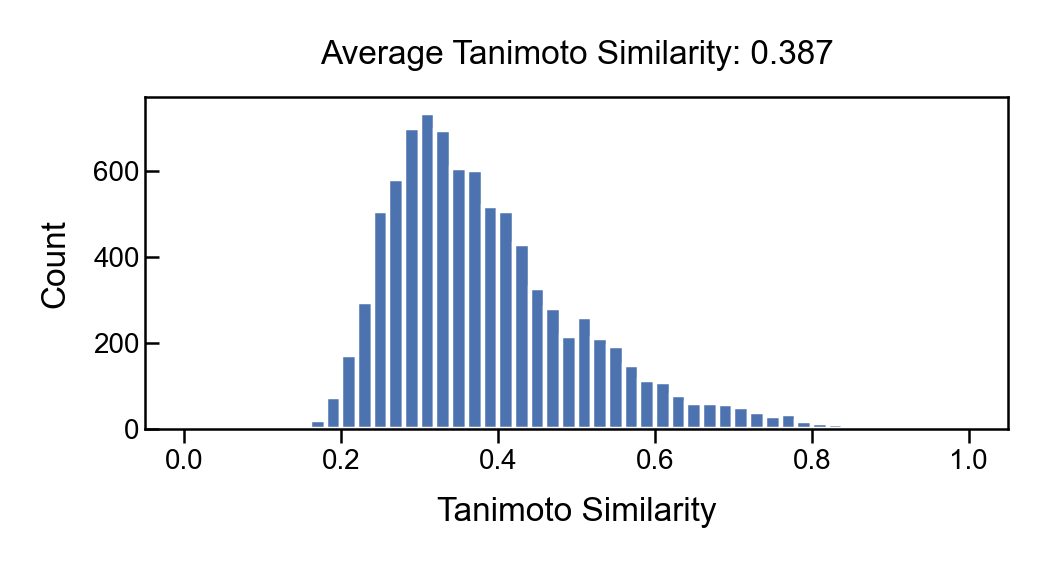

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# max_tani_sims: 1D numpy array with values in [0, 1]
# Example:
# max_tani_sims = np.random.rand(1000)

plt.figure(figsize=(2.6, 1.4), dpi=400)
plt.hist(max_tani_sims, bins=50, range=(0,1))

plt.xlabel("Tanimoto Similarity")
plt.ylabel("Count")
plt.title(f"Average Tanimoto Similarity: {max_tani_sims.mean():.3f}")

plt.tight_layout()
plt.savefig(
    'results/figs_iceberg/weave_acc/' + f"msnlib_nist_sim.pdf", bbox_inches="tight", transparent=True
)